In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('salary_prediction_data.csv')
df.head()

,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,High School,8,Urban,Manager,63,Male,84620.053665
1,PhD,11,Suburban,Director,59,Male,142591.255894
2,Bachelor,28,Suburban,Manager,61,Female,97800.255404
3,High School,29,Rural,Director,45,Male,96834.671282
4,PhD,25,Urban,Analyst,26,Female,132157.786175


In [3]:
df.shape

(1000, 7)

In [4]:
df.isna().sum()

Education     0
Experience    0
Location      0
Job_Title     0
Age           0
Gender        0
Salary        0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Education   1000 non-null   str    
 1   Experience  1000 non-null   int64  
 2   Location    1000 non-null   str    
 3   Job_Title   1000 non-null   str    
 4   Age         1000 non-null   int64  
 5   Gender      1000 non-null   str    
 6   Salary      1000 non-null   float64
dtypes: float64(1), int64(2), str(4)
memory usage: 54.8 KB


In [6]:
df['Education'].unique()

<StringArray>
['High School', 'PhD', 'Bachelor', 'Master']
Length: 4, dtype: str

In [7]:
df['Education']=df['Education'].replace({'High School':0, 'PhD':1, 'Bachelor':2, 'Master':3})
df['Education']=df['Education'].astype(int)


In [8]:
df['Location'].unique()

<StringArray>
['Urban', 'Suburban', 'Rural']
Length: 3, dtype: str

In [9]:
df['Location']=df['Location'].replace({'Urban':0, 'Suburban':1, 'Rural':2})
df['Location']=df['Location'].astype(int)


In [10]:
df['Job_Title'].unique()

<StringArray>
['Manager', 'Director', 'Analyst', 'Engineer']
Length: 4, dtype: str

In [11]:
df['Job_Title']=df['Job_Title'].replace({'Manager':0, 'Director':1, 'Analyst':2, 'Engineer':3})
df['Job_Title']=df['Job_Title'].astype(int)

In [12]:
df['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [13]:
df['Gender']=df['Gender'].replace({'Male':0, 'Female':1})
df['Gender']=df['Gender'].astype(int)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Education   1000 non-null   int64  
 1   Experience  1000 non-null   int64  
 2   Location    1000 non-null   int64  
 3   Job_Title   1000 non-null   int64  
 4   Age         1000 non-null   int64  
 5   Gender      1000 non-null   int64  
 6   Salary      1000 non-null   float64
dtypes: float64(1), int64(6)
memory usage: 54.8 KB


In [15]:
df.columns

Index(['Education', 'Experience', 'Location', 'Job_Title', 'Age', 'Gender',
       'Salary'],
      dtype='str')

In [16]:
corr_mtx=df.corr()['Salary']
corr_mtx

Education     0.296545
Experience    0.341918
Location     -0.177018
Job_Title    -0.245507
Age          -0.053174
Gender       -0.028173
Salary        1.000000
Name: Salary, dtype: float64

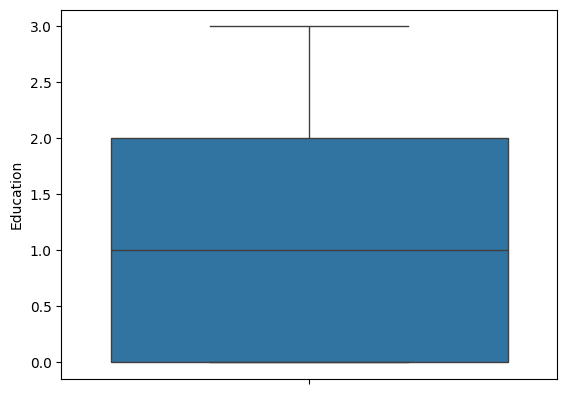

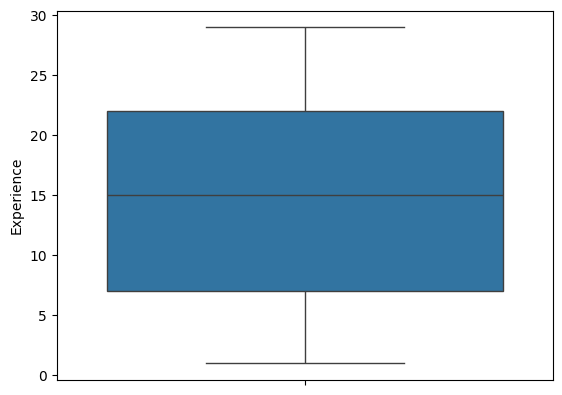

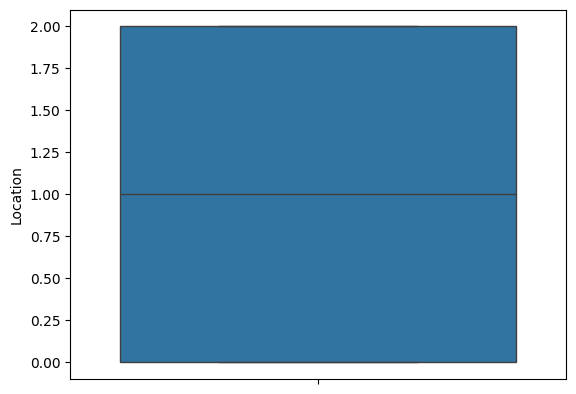

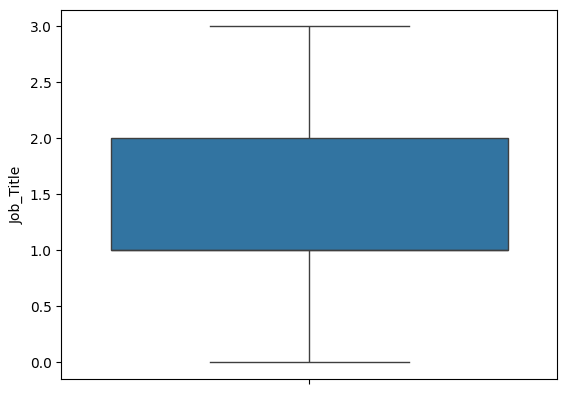

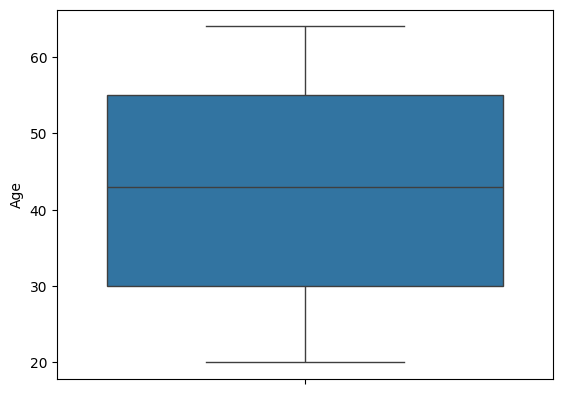

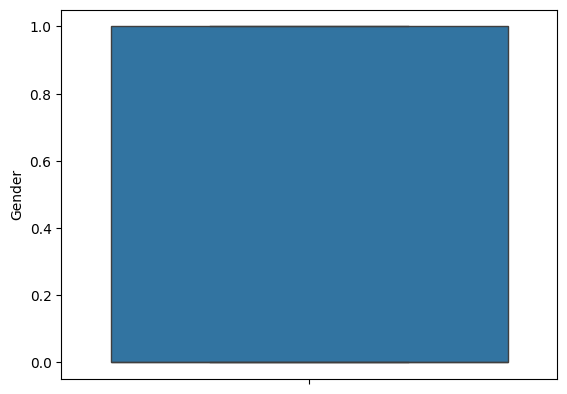

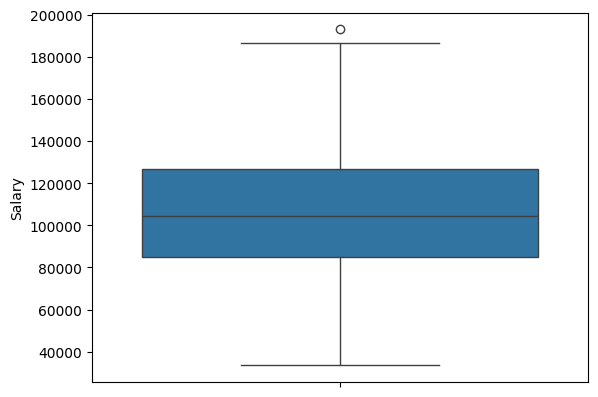

In [17]:
import seaborn as sns
for i in df.columns:
    sns.boxplot(df[i])
    plt.show()

In [18]:
df['Salary'].unique()

array([ 84620.05366452, 142591.25589431,  97800.25540414,  96834.6712815 ,
       132157.78617466, 156312.9362084 , 130567.64945545, 148707.74075901,
        95945.27542859, 133339.3896823 , 101164.09236529, 124251.98714687,
        55066.11435258, 124972.50876978, 126139.1367011 ,  81007.19945085,
        60693.92471393, 103386.07028993, 140042.1389185 ,  86048.11608072,
        73861.9929533 , 106145.0055121 , 142981.59047925,  96620.92938816,
        89426.94711719, 104762.3985202 , 101747.54077443,  68635.08828494,
        90550.4794241 ,  75559.24411373,  87433.4986452 ,  57615.23341761,
       126043.14343329,  73043.43575163, 134560.19300401,  95804.26144082,
        99694.53954355, 153930.93385163, 151123.33589342,  81462.71866944,
       106019.02039637, 142122.66726826,  66858.43105342,  82060.73292914,
       107935.40344896,  70251.76628382, 118799.44006116, 100369.02351604,
       100038.76802249, 164542.83698805,  95726.36718568,  96598.32495003,
        82628.14830429,  

In [19]:
df[df['Salary']>170000]

,Education,Experience,Location,Job_Title,Age,Gender,Salary
211,1,17,0,1,50,0,171403.036410
438,1,20,1,1,53,1,193016.602150
527,1,28,1,1,36,0,175671.309406
603,1,29,0,1,56,0,186452.845727


In [20]:
df.head()

,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,0,8,0,0,63,0,84620.053665
1,1,11,1,1,59,0,142591.255894
2,2,28,1,0,61,1,97800.255404
3,0,29,2,1,45,0,96834.671282
4,1,25,0,2,26,1,132157.786175


In [21]:
df.drop(columns='Gender',inplace=True)

In [22]:
from sklearn.feature_selection import SelectKBest,f_regression
sk=SelectKBest(score_func=f_regression,k='all')
sk.fit(df.drop('Salary',axis=1),df['Salary'])

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_r...0020F336F0E00>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",'all'


In [23]:
sk.scores_

array([ 96.22474243, 132.11992735,  32.28450511,  64.01158972,
         2.82976837])

In [24]:
cor_df = pd.DataFrame({'col_name':df.drop('Salary',axis=1).columns,'score':sk.scores_})
cor_df

,col_name,score
0,Education,96.224742
1,Experience,132.119927
2,Location,32.284505
3,Job_Title,64.011590
4,Age,2.829768


In [25]:
x=df.iloc[:,:6]
y=df['Salary']

In [26]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(criterion='friedman_mse',max_depth=5,min_samples_split=5)
dt.fit(xtrain,ytrain)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'friedman_mse'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_lea

In [28]:
ypred=dt.predict(xtest)

In [ ]:
from sklearn.metrics import r2_score
r2_score(ytest,ypred)

0.9965950983561748

In [31]:
ytrain_pred = dt.predict(xtrain)
r2_score(ytrain,ytrain_pred)

0.9982674540874357

In [32]:
if r2_score(ytrain,ytrain_pred)<.60:
    print("underfit")
elif r2_score(ytrain,ytrain_pred)>r2_score(ytest,ypred)+0.10:
    print("overfit")
else:
    print("good fit")

good fit
